In [7]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [75]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_excel(
    r"C:\Users\Amey\Desktop\Amey\Python\100\Preprocessing\100_Pre_done_Combined.xlsx"
)

print(f"Original Shape: {df.shape}")

# Clean SLoc
df['SLoc'] = (
    df['SLoc']
    .astype(str)
    .str.strip()
)

# Convert date
df['Pstng Date'] = pd.to_datetime(
    df['Pstng Date'],
    errors='coerce'
)

# Keep only outward movements
df_consumption = df

# Convert consumption to positive values
df_consumption['Consumption'] = abs(df['Quantity'])

print((df['Quantity'] > 0).sum(), "positive rows")
print((df['Quantity'] < 0).sum(), "negative rows")

print(f"Unique SLocs: {df_consumption['SLoc'].nunique()}")
print(
    f"Date Range: "
    f"{df_consumption['Pstng Date'].min()} -> "
    f"{df_consumption['Pstng Date'].max()}"
)

print(
    f"Total Consumption: "
    f"{df_consumption['Consumption'].sum():,.2f}"
)



Original Shape: (21349, 17)
1034 positive rows
20315 negative rows
Unique SLocs: 41
Date Range: 2020-01-04 00:00:00 -> 2026-04-30 00:00:00
Total Consumption: 21,442.00


In [28]:
invalid_dates = df['Pstng Date'].isna().sum()

print(f"Invalid Dates: {invalid_dates}")

if invalid_dates > 0:
    print("WARNING: Rows with invalid dates detected")

Invalid Dates: 0


In [ ]:
# ==========================================
# Convert Date Columns
# ==========================================

df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])

df['Year'] = df['Pstng Date'].dt.year
df['Month'] = df['Pstng Date'].dt.month

df.head()

,Material,SLoc,Quantity,Pstng Date,order,Equipment,Technician name,Year,Tavg,Tmax,Tmin,RH,Month,Season,Delta_T,Region,Location
0,100,5023,-1,2020-01-04,48550533,10930429,Anil Sharma,2020,12.94,21.27,7.26,58.52,1,Winter,14.01,North1,Haryana
1,100,5024,-1,2020-01-06,48556766,10844557,Jogendra Singh,2020,14.94,22.58,9.03,56.47,1,Winter,13.55,North1,Jaipur
2,100,5030,-1,2020-01-06,48550093,10517828,Himanshu Kushwaha,2020,13.70,21.92,8.25,55.23,1,Winter,13.67,North1,Delhi
3,100,5002,-1,2020-01-06,48550185,10519283,Prasad Chokhat,2020,22.83,30.49,16.34,68.83,1,Winter,14.15,West1,Navi Mumbai
4,100,5044,-1,2020-01-06,48554032,10836205,Joby Varghese,2020,28.71,32.68,25.08,68.80,1,Winter,7.60,South,Cochin


In [32]:
monthly_consumption = (
    df_consumption.groupby([
            'SLoc',
            pd.Grouper(
                key='Pstng Date',
                freq='MS'
            )
        ],
        dropna=False
    )['Consumption']
    .sum()
    .reset_index()
)

print("\nAfter Monthly Aggregation")
print(monthly_consumption.shape)

print(
    f"Consumption Sum: "
    f"{monthly_consumption['Consumption'].sum():,.2f}"
)
assert np.isclose(
    df_consumption['Consumption'].sum(),
    monthly_consumption['Consumption'].sum()
), "Consumption mismatch after aggregation!"


After Monthly Aggregation
(1576, 3)
Consumption Sum: 20,388.00


In [34]:
start_month = (
    monthly_consumption['Pstng Date']
    .min()
)

end_month = (
    monthly_consumption['Pstng Date']
    .max()
)

all_months = pd.date_range(
    start=start_month,
    end=end_month,
    freq='MS'
)
all_slocs = (
    monthly_consumption['SLoc']
    .unique()
)

full_index = pd.MultiIndex.from_product(
    [all_slocs, all_months],
    names=['SLoc', 'Pstng Date']
)

In [36]:
monthly_complete = (
    monthly_consumption
    .set_index(['SLoc', 'Pstng Date'])
    .reindex(full_index)
    .reset_index()
)

monthly_complete['Consumption'] = (
    monthly_complete['Consumption']
    .fillna(0)
)
original_sum = monthly_consumption['Consumption'].sum()

new_sum = monthly_complete['Consumption'].sum()

print(f"Original Sum : {original_sum:,.2f}")
print(f"Reindexed Sum: {new_sum:,.2f}")

assert np.isclose(
    original_sum,
    new_sum
), "Consumption changed after reindex!"

Original Sum : 20,388.00
Reindexed Sum: 20,388.00


In [ ]:
monthly_complete['Month_Year'] = (
    monthly_complete['Pstng Date']
    .dt.strftime('%b %Y')
)
month_order = (
    monthly_complete[
        ['Pstng Date', 'Month_Year']
    ]
    .drop_duplicates()
    .sort_values('Pstng Date')
)['Month_Year']
wide_consumption = (
    monthly_complete
    .pivot(
        index='SLoc',
        columns='Month_Year',
        values='Consumption'
    )
    .reindex(columns=month_order)
    .reset_index()
)

In [40]:
test_sloc = (
    monthly_complete['SLoc']
    .iloc[0]
)

long_sum = (
    monthly_complete
    .loc[
        monthly_complete['SLoc'] == test_sloc,
        'Consumption'
    ]
    .sum()
)

wide_sum = (
    wide_consumption
    .loc[
        wide_consumption['SLoc'] == test_sloc
    ]
    .drop(columns='SLoc')
    .sum(axis=1)
    .iloc[0]
)

print(test_sloc)
print(long_sum)
print(wide_sum)
monthly_complete.to_csv(
    "SLoc_Wise_Consumption.csv",
    index=False
)

wide_consumption.to_csv(
    "SLoc_Wise_Consumption_Wide.csv",
    index=False
)

5001
1958.0
1958.0


In [58]:
# ==========================================
# Aggregate Monthly Weather Data
# ==========================================

weather_monthly = (
    df.groupby(
        [
            'SLoc',
            pd.Grouper(
                key='Pstng Date',
                freq='MS'
            )
        ]
    )
    .agg(
        {
            'Tavg':'mean',
            'Tmax':'mean',
            'Tmin':'mean',
            'RH':'mean',
            'Delta_T':'mean'
        }
    )
    .reset_index()
)

weather_monthly.head()
monthly = monthly_complete.merge(
    weather_monthly,
    on=['SLoc','Pstng Date'],
    how='left'
)

monthly.head()

,SLoc,Pstng Date,Consumption,Month_Year,Tavg,Tmax,Tmin,RH,Delta_T
0,5001,2020-01-01,19.0,Jan 2020,21.661579,29.081579,15.856842,67.084211,13.224737
1,5001,2020-02-01,21.0,Feb 2020,26.452381,35.247619,20.002381,45.686667,15.245238
2,5001,2020-03-01,15.0,Mar 2020,25.628667,33.601333,19.414000,52.732000,14.187333
3,5001,2020-04-01,0.0,Apr 2020,NaN,NaN,NaN,NaN,NaN
4,5001,2020-05-01,5.0,May 2020,32.292000,39.894000,26.452000,57.042000,13.442000


In [59]:
# ==========================================
# Calendar Features
# ==========================================

monthly['Year'] = monthly['Pstng Date'].dt.year
monthly['Month'] = monthly['Pstng Date'].dt.month

monthly['Quarter'] = (
    monthly['Pstng Date']
    .dt
    .quarter
)

monthly['month_sin'] = np.sin(
    2*np.pi*monthly['Month']/12
)

monthly['month_cos'] = np.cos(
    2*np.pi*monthly['Month']/12
)

monthly.head()

,SLoc,Pstng Date,Consumption,Month_Year,Tavg,Tmax,Tmin,RH,Delta_T,Year,Month,Quarter,month_sin,month_cos
0,5001,2020-01-01,19.0,Jan 2020,21.661579,29.081579,15.856842,67.084211,13.224737,2020,1,1,0.500000,8.660254e-01
1,5001,2020-02-01,21.0,Feb 2020,26.452381,35.247619,20.002381,45.686667,15.245238,2020,2,1,0.866025,5.000000e-01
2,5001,2020-03-01,15.0,Mar 2020,25.628667,33.601333,19.414000,52.732000,14.187333,2020,3,1,1.000000,6.123234e-17
3,5001,2020-04-01,0.0,Apr 2020,NaN,NaN,NaN,NaN,NaN,2020,4,2,0.866025,-5.000000e-01
4,5001,2020-05-01,5.0,May 2020,32.292000,39.894000,26.452000,57.042000,13.442000,2020,5,2,0.500000,-8.660254e-01


In [60]:
# ==========================================
# Lag Features
# ==========================================

for lag in [1,2,3,6,12]:

    monthly[f'lag_{lag}'] = (
        monthly
        .groupby('SLoc')['Consumption']
        .shift(lag)
    )

monthly.head()

,SLoc,Pstng Date,Consumption,Month_Year,Tavg,Tmax,Tmin,RH,Delta_T,Year,Month,Quarter,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12
0,5001,2020-01-01,19.0,Jan 2020,21.661579,29.081579,15.856842,67.084211,13.224737,2020,1,1,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN
1,5001,2020-02-01,21.0,Feb 2020,26.452381,35.247619,20.002381,45.686667,15.245238,2020,2,1,0.866025,5.000000e-01,19.0,NaN,NaN,NaN,NaN
2,5001,2020-03-01,15.0,Mar 2020,25.628667,33.601333,19.414000,52.732000,14.187333,2020,3,1,1.000000,6.123234e-17,21.0,19.0,NaN,NaN,NaN
3,5001,2020-04-01,0.0,Apr 2020,NaN,NaN,NaN,NaN,NaN,2020,4,2,0.866025,-5.000000e-01,15.0,21.0,19.0,NaN,NaN
4,5001,2020-05-01,5.0,May 2020,32.292000,39.894000,26.452000,57.042000,13.442000,2020,5,2,0.500000,-8.660254e-01,0.0,15.0,21.0,NaN,NaN


In [61]:
# ==========================================
# Rolling Features
# ==========================================

monthly['roll_mean_3'] = (
    monthly.groupby('SLoc')['Consumption']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3)
         .mean()
    )
)

monthly['roll_mean_6'] = (
    monthly.groupby('SLoc')['Consumption']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(6)
         .mean()
    )
)

monthly['roll_mean_12'] = (
    monthly.groupby('SLoc')['Consumption']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(12)
         .mean()
    )
)

monthly['roll_std_3'] = (
    monthly.groupby('SLoc')['Consumption']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3)
         .std()
    )
)

monthly['roll_std_6'] = (
    monthly.groupby('SLoc')['Consumption']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(6)
         .std()
    )
)

monthly['roll_std_12'] = (
    monthly.groupby('SLoc')['Consumption']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(12)
         .std()
    )
)

monthly['roll_max_3'] = (
    monthly.groupby('SLoc')['Consumption']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3)
         .max()
    )
)

monthly['roll_min_3'] = (
    monthly.groupby('SLoc')['Consumption']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3)
         .min()
    )
)

monthly.head()

,SLoc,Pstng Date,Consumption,Month_Year,Tavg,Tmax,Tmin,RH,Delta_T,Year,Month,Quarter,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_mean_12,roll_std_3,roll_std_6,roll_std_12,roll_max_3,roll_min_3
0,5001,2020-01-01,19.0,Jan 2020,21.661579,29.081579,15.856842,67.084211,13.224737,2020,1,1,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5001,2020-02-01,21.0,Feb 2020,26.452381,35.247619,20.002381,45.686667,15.245238,2020,2,1,0.866025,5.000000e-01,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5001,2020-03-01,15.0,Mar 2020,25.628667,33.601333,19.414000,52.732000,14.187333,2020,3,1,1.000000,6.123234e-17,21.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5001,2020-04-01,0.0,Apr 2020,NaN,NaN,NaN,NaN,NaN,2020,4,2,0.866025,-5.000000e-01,15.0,21.0,19.0,NaN,NaN,18.333333,NaN,NaN,3.055050,NaN,NaN,21.0,15.0
4,5001,2020-05-01,5.0,May 2020,32.292000,39.894000,26.452000,57.042000,13.442000,2020,5,2,0.500000,-8.660254e-01,0.0,15.0,21.0,NaN,NaN,12.000000,NaN,NaN,10.816654,NaN,NaN,21.0,0.0


In [73]:
# ==========================================
# Remove NaNs from Lag/Rolling Features
# ==========================================

monthly = monthly.dropna().reset_index(drop=True)

print(monthly.shape)
print("Before:", monthly.shape)

monthly = monthly.dropna()

print("After:", monthly.shape)
monthly.head()

(1424, 27)
Before: (1424, 27)
After: (1424, 27)


,SLoc,Pstng Date,Consumption,Month_Year,Tavg,Tmax,Tmin,RH,Delta_T,Year,Month,Quarter,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_mean_12,roll_std_3,roll_std_6,roll_std_12,roll_max_3,roll_min_3
0,5001,2021-01-01,34.0,Jan 2021,23.798077,31.343462,18.510000,61.378077,12.833462,2021,1,1,0.500000,8.660254e-01,15.0,16.0,17.0,14.0,19.0,16.000000,16.333333,15.000000,1.000000,2.503331,6.522688,17.0,15.0
1,5001,2021-02-01,17.0,Feb 2021,25.028824,34.398824,18.077059,45.559412,16.321765,2021,2,1,0.866025,5.000000e-01,34.0,15.0,16.0,15.0,21.0,21.666667,19.666667,16.250000,10.692677,7.366591,8.497326,34.0,15.0
2,5001,2021-03-01,29.0,Mar 2021,29.422500,38.661071,22.167143,39.315000,16.493929,2021,3,1,1.000000,6.123234e-17,17.0,34.0,15.0,21.0,15.0,22.000000,20.000000,15.916667,10.440307,7.155418,8.371579,34.0,15.0
3,5001,2021-04-01,12.0,Apr 2021,30.856667,38.848333,24.702500,53.057500,14.145833,2021,4,2,0.866025,-5.000000e-01,29.0,17.0,34.0,17.0,0.0,26.666667,21.333333,17.083333,8.736895,8.066391,9.169696,34.0,17.0
4,5001,2021-05-01,11.0,May 2021,30.438182,35.420909,26.668182,67.158182,8.752727,2021,5,2,0.500000,-8.660254e-01,12.0,29.0,17.0,16.0,5.0,19.333333,20.500000,18.083333,8.736895,8.826098,7.668807,29.0,12.0


In [63]:
# ==========================================
# Feature Selection
# ==========================================

FEATURES = [

    'Year',

    'month_sin',
    'month_cos',
    'Quarter',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_6',
    'lag_12',

    'roll_mean_3',
    'roll_mean_6',
    'roll_mean_12',

    'roll_std_3',
    'roll_std_6',
    'roll_std_12',

    'roll_max_3',
    'roll_min_3',

    'Tavg',
    'Tmax',
    'Tmin',
    'RH',
    'Delta_T'
]

TARGET = 'Consumption'

In [64]:
# ==========================================
# Train Test Split
# ==========================================

train = monthly[
    monthly['Pstng Date'] < '2025-01-01'
].copy()

test = monthly[
    (monthly['Pstng Date'] >= '2025-01-01') &
    (monthly['Pstng Date'] <= '2026-04-30')
].copy()

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

Train Shape : (1065, 27)
Test Shape : (359, 27)


In [65]:
# ==========================================
# Create X and y
# ==========================================

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [66]:
# ==========================================
# Evaluation Metrics
# ==========================================

def wmape(y_true, y_pred):

    return (
        np.sum(np.abs(y_true - y_pred))
        /
        np.sum(np.abs(y_true))
    ) * 100


def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    wmape_score = wmape(
        y_true,
        y_pred
    )

    return pd.DataFrame({

        'Model':[name],
        'MAE':[mae],
        'RMSE':[rmse],
        'MAPE':[mape],
        'WMAPE':[wmape_score]

    })

In [67]:
# ==========================================
# XGBoost
# ==========================================

xgb_model = XGBRegressor(

    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,

    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

test['XGB_Pred'] = xgb_model.predict(
    X_test
)

xgb_metrics = evaluate_model(
    'XGBoost',
    y_test,
    test['XGB_Pred']
)

xgb_metrics

,Model,MAE,RMSE,MAPE,WMAPE
0,XGBoost,5.809897,12.771178,2.556683e+16,30.524706


In [68]:
# ==========================================
# CatBoost
# ==========================================

cat_model = CatBoostRegressor(

    iterations=500,
    learning_rate=0.05,
    depth=6,

    verbose=0,

    random_state=42
)

cat_model.fit(
    X_train,
    y_train
)

test['CAT_Pred'] = cat_model.predict(
    X_test
)

cat_metrics = evaluate_model(
    'CatBoost',
    y_test,
    test['CAT_Pred']
)

cat_metrics

,Model,MAE,RMSE,MAPE,WMAPE
0,CatBoost,5.142991,11.75242,2.031142e+16,27.020837


In [69]:
# ==========================================
# LightGBM
# ==========================================

lgbm_model = LGBMRegressor(

    n_estimators=500,
    learning_rate=0.05,

    random_state=42
)

lgbm_model.fit(
    X_train,
    y_train
)

test['LGBM_Pred'] = lgbm_model.predict(
    X_test
)

lgbm_metrics = evaluate_model(
    'LightGBM',
    y_test,
    test['LGBM_Pred']
)

lgbm_metrics

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2776
[LightGBM] [Info] Number of data points in the train set: 1065, number of used features: 22
[LightGBM] [Info] Start training from score 11.884507


,Model,MAE,RMSE,MAPE,WMAPE
0,LightGBM,6.061228,12.994481,2.286274e+16,31.845174


In [70]:
# ==========================================
# Random Forest
# ==========================================

rf_model = RandomForestRegressor(

    n_estimators=500,

    random_state=42,

    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

test['RF_Pred'] = rf_model.predict(
    X_test
)

rf_metrics = evaluate_model(
    'RandomForest',
    y_test,
    test['RF_Pred']
)

rf_metrics

,Model,MAE,RMSE,MAPE,WMAPE
0,RandomForest,5.005727,11.344431,2.136387e+16,26.299663


In [71]:
# ==========================================
# Compare Models
# ==========================================

model_metrics = pd.concat([

    xgb_metrics,
    cat_metrics,
    lgbm_metrics,
    rf_metrics

])

model_metrics.sort_values(
    'WMAPE'
)

,Model,MAE,RMSE,MAPE,WMAPE
0,RandomForest,5.005727,11.344431,2.136387e+16,26.299663
0,CatBoost,5.142991,11.752420,2.031142e+16,27.020837
0,XGBoost,5.809897,12.771178,2.556683e+16,30.524706
0,LightGBM,6.061228,12.994481,2.286274e+16,31.845174


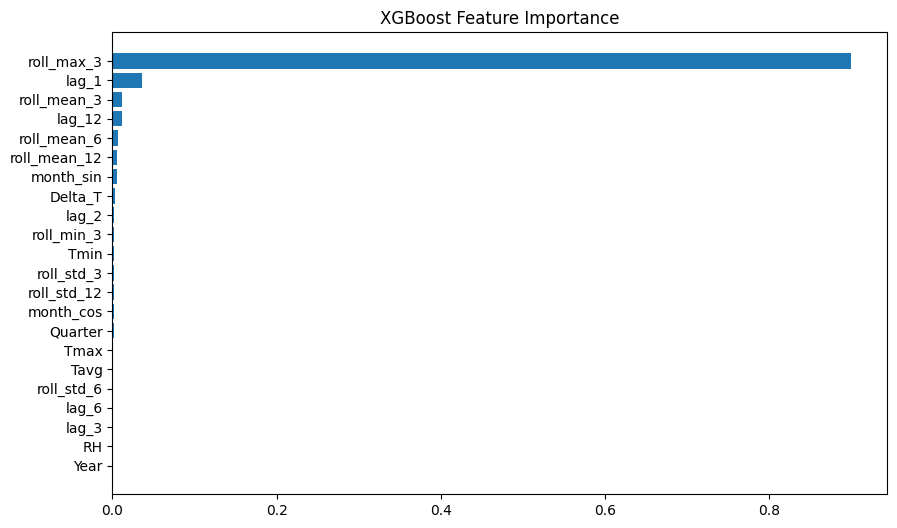

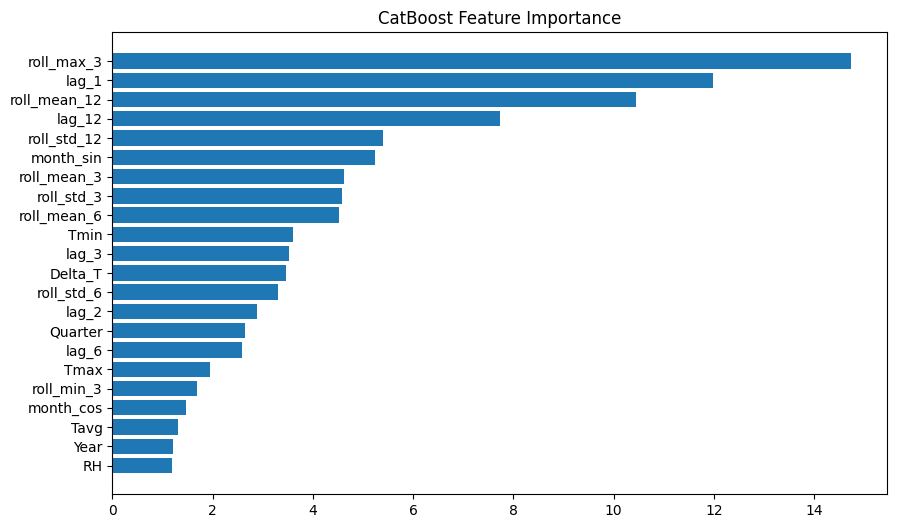

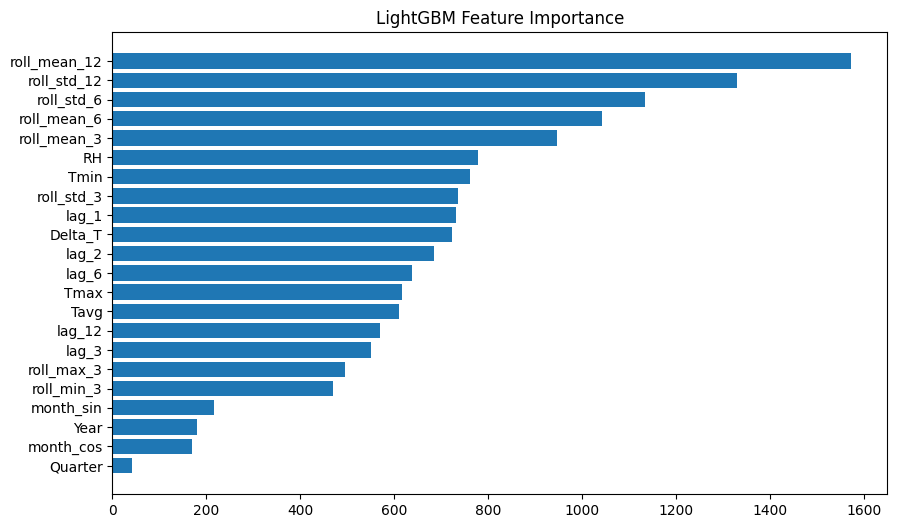

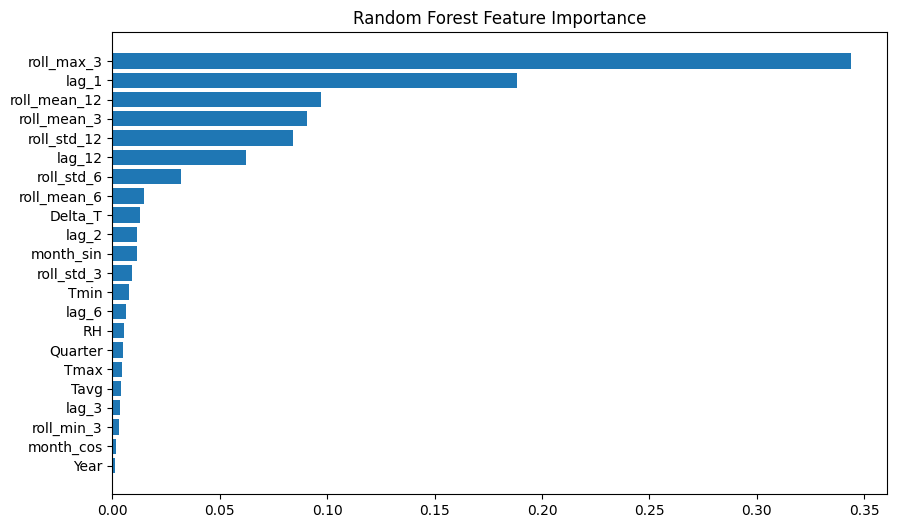

,Feature,XGB,CAT,LGBM,RF
0,Year,0.000312,1.214738,181,0.001399
1,month_sin,0.005919,5.239575,217,0.011345
2,month_cos,0.001469,1.476474,169,0.001699
3,Quarter,0.001442,2.635023,41,0.004672
4,lag_1,0.036279,11.973057,731,0.188537
5,lag_2,0.002258,2.878347,684,0.011558
6,lag_3,0.000945,3.518528,550,0.003660
7,lag_6,0.001038,2.586119,638,0.006154
8,lag_12,0.011363,7.734209,570,0.062253
9,roll_mean_3,0.011913,4.611884,946,0.090559


In [72]:
importance_xgb = pd.DataFrame({

    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_

})

importance_xgb = importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

importance_xgb
plt.figure(figsize=(10,6))

plt.barh(
    importance_xgb['Feature'],
    importance_xgb['Importance']
)

plt.gca().invert_yaxis()

plt.title('XGBoost Feature Importance')

plt.show()
importance_cat = pd.DataFrame({

    'Feature': FEATURES,

    'Importance': cat_model.get_feature_importance()

})

importance_cat = importance_cat.sort_values(

    by='Importance',

    ascending=False

)

importance_cat

plt.figure(figsize=(10,6))

plt.barh(

    importance_cat['Feature'],

    importance_cat['Importance']

)

plt.gca().invert_yaxis()

plt.title('CatBoost Feature Importance')

plt.show()
importance_lgbm = pd.DataFrame({

    'Feature': FEATURES,

    'Importance': lgbm_model.feature_importances_

})

importance_lgbm = importance_lgbm.sort_values(

    by='Importance',

    ascending=False

)

importance_lgbm

plt.figure(figsize=(10,6))

plt.barh(

    importance_lgbm['Feature'],

    importance_lgbm['Importance']

)

plt.gca().invert_yaxis()

plt.title('LightGBM Feature Importance')

plt.show()

importance_rf = pd.DataFrame({

    'Feature': FEATURES,

    'Importance': rf_model.feature_importances_

})

importance_rf = importance_rf.sort_values(

    by='Importance',

    ascending=False

)

importance_rf

plt.figure(figsize=(10,6))

plt.barh(

    importance_rf['Feature'],

    importance_rf['Importance']

)

plt.gca().invert_yaxis()

plt.title('Random Forest Feature Importance')

plt.show()
comparison = pd.DataFrame({

    'Feature': FEATURES,

    'XGB': xgb_model.feature_importances_,

    'CAT': cat_model.get_feature_importance(),

    'LGBM': lgbm_model.feature_importances_,

    'RF': rf_model.feature_importances_

})

comparison